# Laboratory Assignment №2
## Task 1 — House Price Prediction using Multiple Linear Regression
**Students:** Kazbek Assanbek, Yerserik  
**Group:** IT2-2302

This notebook predicts the median house value from district-level housing characteristics. It is designed to run from top to bottom using the included `california_housing.csv` file.

## 1. Problem description and theory
The task is supervised regression: each row describes one California census district and the target is its median house value in US dollars. The multiple linear regression model is

$$\hat{y}=\beta_0+\beta_1x_1+\beta_2x_2+\cdots+\beta_px_p.$$

Here, $\hat{y}$ is the predicted price, $\beta_0$ is the intercept, $\beta_j$ is a coefficient, and $x_j$ is a feature. In matrix/probabilistic form, $y=X\beta+\varepsilon$, with the classical Gaussian interpretation $\varepsilon\sim N(0,\sigma^2)$. The model assumes approximate linearity, independent errors, reasonably constant error variance, and classical regression prefers low multicollinearity, but the VIF analysis shows this condition is not fully satisfied in this dataset. Normal residuals are mainly needed for classical inference, not merely for prediction.

Training minimizes $MSE=\frac1n\sum_i(y_i-\hat y_i)^2$; squaring gives larger errors a larger penalty.

## 2. Imports and data loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

RANDOM_STATE = 42
df = pd.read_csv('california_housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Initial inspection
Dataset source: **California Housing Prices — Kaggle — Cam Nugent** ([dataset page](https://www.kaggle.com/datasets/camnugent/california-housing-prices)). This is the CSV `housing.csv` version, not sklearn's `fetch_california_housing` object. One row represents a census district. The target is `median_house_value`; the other columns describe location, age, rooms, population, income, and ocean proximity.

In [2]:
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isna().sum())
print('\nDescriptive statistics:')
df.describe(include='all').T

Shape: (20640, 10)
Columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Data types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

Missing values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
longitude,20640.0,NaN,NaN,NaN,-119.569704,2.003532,-124.35,-121.8,-118.49,-118.01,-114.31
latitude,20640.0,NaN,NaN,NaN,35.631861,2.135952,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,NaN,NaN,NaN,28.639486,12.585558,1.0,18.0,29.0,37.0,52.0
total_rooms,20640.0,NaN,NaN,NaN,2635.763081,2181.615252,2.0,1447.75,2127.0,3148.0,39320.0
total_bedrooms,20433.0,NaN,NaN,NaN,537.870553,421.38507,1.0,296.0,435.0,647.0,6445.0
population,20640.0,NaN,NaN,NaN,1425.476744,1132.462122,3.0,787.0,1166.0,1725.0,35682.0
households,20640.0,NaN,NaN,NaN,499.53968,382.329753,1.0,280.0,409.0,605.0,6082.0
median_income,20640.0,NaN,NaN,NaN,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,NaN,NaN,NaN,206855.816909,115395.615874,14999.0,119600.0,179700.0,264725.0,500001.0
ocean_proximity,20640,5,<1H OCEAN,9136,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Preprocessing and exploratory analysis
There are numerical and categorical features. Missing numerical values are replaced by the training median, while the categorical value is imputed by its most frequent category. `OneHotEncoder` converts `ocean_proximity` into indicator columns. These operations are inside a pipeline, so they are learned only from the training set and do not leak test information.

Numerical features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical features: ['ocean_proximity']


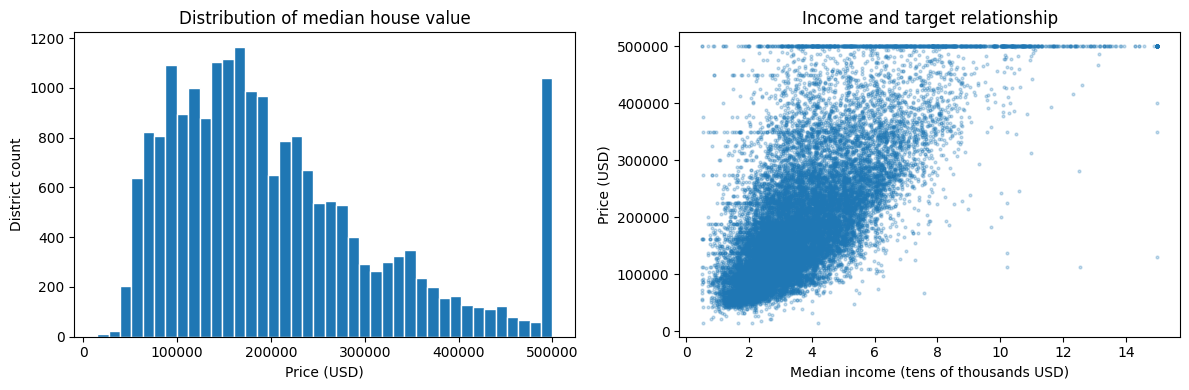

In [3]:
X = df.drop(columns='median_house_value')
y = df['median_house_value']
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
print('Numerical features:', numeric_features)
print('Categorical features:', categorical_features)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(y, bins=40, edgecolor='white')
ax[0].set(title='Distribution of median house value', xlabel='Price (USD)', ylabel='District count')
ax[1].scatter(df['median_income'], y, s=4, alpha=.25)
ax[1].set(title='Income and target relationship', xlabel='Median income (tens of thousands USD)', ylabel='Price (USD)')
plt.tight_layout(); plt.savefig('eda.png', dpi=160); plt.show()

## 5. Feature/target separation and train/test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
print('Training rows:', len(X_train), '| Test rows:', len(X_test))

Training rows: 16512 | Test rows: 4128


## 6. Model initialization and fitting

In [5]:
numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scale', StandardScaler())])
categorical_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))])
preprocessor = ColumnTransformer([('numeric', numeric_pipe, numeric_features), ('categorical', categorical_pipe, categorical_features)])
model = Pipeline([('preprocessor', preprocessor), ('regressor', LinearRegression())])
with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
print('LinearRegression fitted successfully.')

LinearRegression fitted successfully.


## 7. Evaluation

In [6]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
results = pd.DataFrame({'Metric':['MSE','MAE','R²'], 'Value':[mse,mae,r2]})
results

,Metric,Value
0,MSE,4.908291e+09
1,MAE,5.067049e+04
2,R²,6.254383e-01


MSE is the average squared prediction error and is expressed in squared dollars. MAE is the average absolute error in dollars, so it is easier to interpret. R² is the proportion of target variation explained by the model on the test set.

## 8. Regression coefficients

In [7]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
reference_category = model.named_steps['preprocessor'].named_transformers_['categorical'].named_steps['onehot'].categories_[0][0]
print('Dropped/reference ocean_proximity category:', reference_category)
print('Maximum actual target:', y.max(), '| Observations at cap:', (y == y.max()).sum())
raw_coefficients = model.named_steps['regressor'].coef_.copy()
raw_coefficients[:len(numeric_features)] = raw_coefficients[:len(numeric_features)] / model.named_steps['preprocessor'].named_transformers_['numeric'].named_steps['scale'].scale_
coefficients = pd.DataFrame({'feature':feature_names, 'coefficient':raw_coefficients})
coefficients['absolute'] = coefficients['coefficient'].abs()
coefficients.sort_values('absolute', ascending=False).drop(columns='absolute').head(15)

Dropped/reference ocean_proximity category: <1H OCEAN
Maximum actual target: 500001.0 | Observations at cap: 965


,feature,coefficient
9,categorical__ocean_proximity_ISLAND,136125.072615
8,categorical__ocean_proximity_INLAND,-39786.656161
7,numeric__median_income,39473.975175
0,numeric__longitude,-26838.273372
1,numeric__latitude,-25468.352050
10,categorical__ocean_proximity_NEAR BAY,-5136.642217
11,categorical__ocean_proximity_NEAR OCEAN,3431.140073
2,numeric__housing_median_age,1102.185084
4,numeric__total_bedrooms,102.789395
6,numeric__households,48.252753


A coefficient is the expected change in predicted target for a one-unit increase in that feature, holding the other inputs fixed. It is an association in this predictive model, not automatically a causal effect. One-hot coefficients are relative to the omitted reference category `NEAR BAY`.

## 9. Multicollinearity analysis

In [8]:
vif_input = sm.add_constant(X_train[numeric_features].fillna(X_train[numeric_features].median()), has_constant='add')
vif_table = pd.DataFrame({'feature':numeric_features, 'VIF':[variance_inflation_factor(vif_input.values, i + 1) for i in range(len(numeric_features))]})
vif_table.sort_values('VIF', ascending=False)

,feature,VIF
4,total_bedrooms,36.307087
6,households,35.824564
3,total_rooms,12.821807
1,latitude,8.798267
0,longitude,8.681823
5,population,6.345431
7,median_income,1.740998
2,housing_median_age,1.257629


Multicollinearity occurs when predictors contain overlapping information. It can make individual coefficients unstable and harder to interpret, although predictions may still be useful. VIF is a diagnostic; values around 5 or 10 are sometimes used as rules of thumb, not universal laws. The categorical indicators are omitted from this compact VIF table because the numerical predictors are the clearest diagnostic here.

## 10. Visualizations

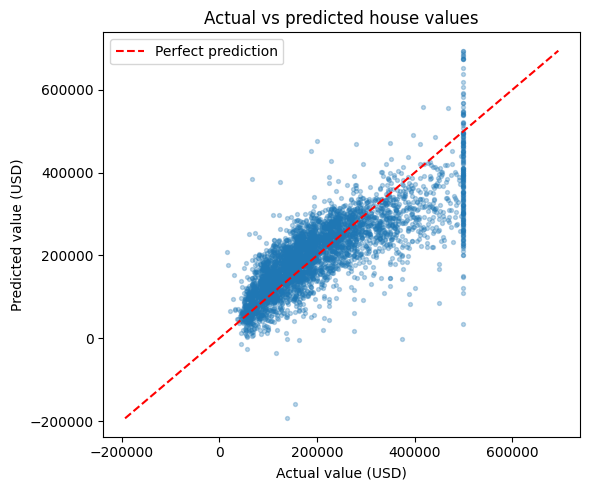

The vertical concentration near actual = $500,001 is caused by multiple observations sharing the dataset maximum target; points near the diagonal have smaller errors.
Minimum predicted value: -193444.91720862282


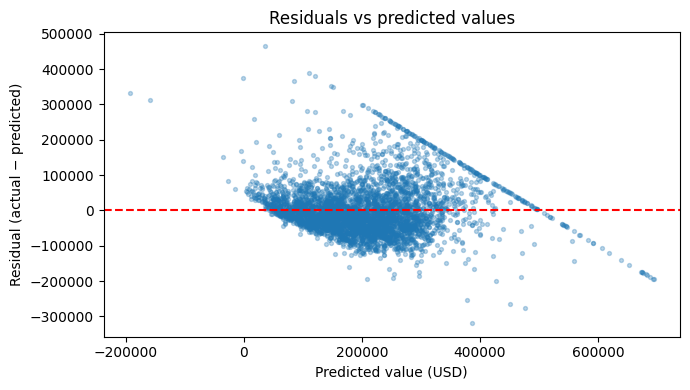

The diagonal residual boundary is caused by the dataset's capped maximum target value of $500,001, not by a plotting error.


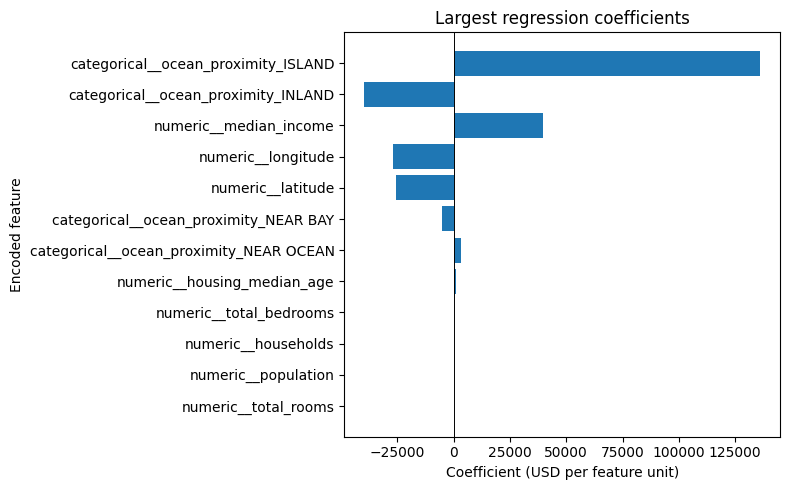

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred, s=8, alpha=.3)
lims=[min(y_test.min(),y_pred.min()),max(y_test.max(),y_pred.max())]
ax.plot(lims,lims,'r--',label='Perfect prediction')
ax.set(title='Actual vs predicted house values', xlabel='Actual value (USD)', ylabel='Predicted value (USD)'); ax.legend(); plt.tight_layout(); plt.savefig('actual_vs_predicted.png', dpi=160); plt.show()
print('The vertical concentration near actual = $500,001 is caused by multiple observations sharing the dataset maximum target; points near the diagonal have smaller errors.')
print('Minimum predicted value:', y_pred.min())

residuals=y_test-y_pred
fig,ax=plt.subplots(figsize=(7,4)); ax.scatter(y_pred,residuals,s=8,alpha=.3); ax.axhline(0,color='r',ls='--')
ax.set(title='Residuals vs predicted values',xlabel='Predicted value (USD)',ylabel='Residual (actual − predicted)'); plt.tight_layout(); plt.savefig('residuals.png', dpi=160); plt.show()
print("The diagonal residual boundary is caused by the dataset's capped maximum target value of $500,001, not by a plotting error.")

top=coefficients.sort_values('absolute').tail(15)
fig,ax=plt.subplots(figsize=(8,5)); ax.barh(top['feature'],top['coefficient']); ax.axvline(0,color='black',lw=.7)
ax.set(title='Largest regression coefficients',xlabel='Coefficient (USD per feature unit)',ylabel='Encoded feature'); plt.tight_layout(); plt.savefig('coefficients.png', dpi=160); plt.show()

## 11. Conclusion
The required multiple linear regression model was trained with a reproducible 80/20 split. The test metrics quantify predictive accuracy, while the coefficient and VIF tables show how interpretation is affected by feature scale and overlapping predictors. The model is a useful baseline, but nonlinear relationships, capped target values, and district-level sampling limit how literally coefficients should be interpreted. Ordinary Linear Regression has an unbounded output, so it may produce unrealistic negative house-price predictions for some observations.